# Section 1 — Assignment 2
# Unsupervised Learning & Data Science Fundamentals

**IOAI 2026 Preparation**

**Topics:** K-Means, PCA, t-SNE/UMAP, DBSCAN, Evaluation Metrics, Cross-Validation, ROC Curves, Feature Engineering, Data Processing

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Show all plots inline.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — K-Means Clustering

1. Use `make_blobs` to generate 400 samples with 4 cluster centers and 2 features. Plot the raw data.

2. Fit K-Means with k=4. Visualize the result: color each point by its assigned cluster and mark the cluster centroids with a distinct marker (e.g., a star or 'X').

3. Implement the **Elbow Method**: train K-Means for k = 1 to 10, record the inertia (within-cluster sum of squares) for each, and plot an elbow curve. At which k does the elbow appear?

4. Run K-Means with k=4 ten times using `init='random'` and ten times using `init='k-means++'`. Compare the distribution of final inertia values using a box plot. Which initialization is more stable and why?

5. K-Means assumes convex, equally-sized clusters. Generate a dataset with `make_moons` and show that K-Means fails on it. Then apply **DBSCAN** and show it succeeds.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons

plt.style.use("seaborn-v0_8-whitegrid")

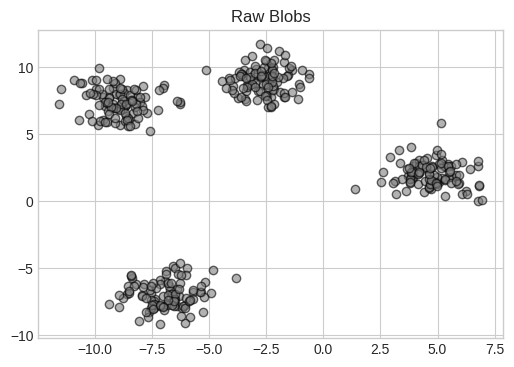

In [ ]:
X_blob, y_blob = make_blobs(
    n_samples=400, centers=4, n_features=2, random_state=42
)
plt.figure(figsize=(6, 4))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c="gray", alpha=0.6, edgecolors="k")
plt.title("Raw Blobs")
plt.show()

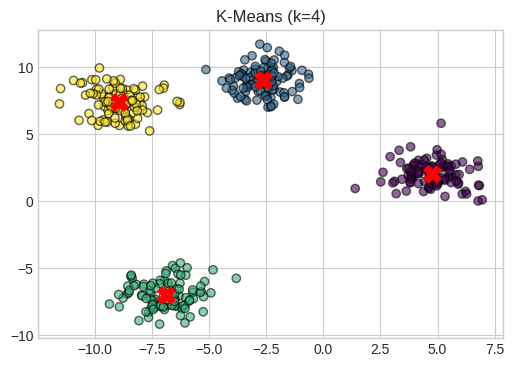

In [ ]:
km = KMeans(n_clusters=4, random_state=42)
labels = km.fit_predict(X_blob)
centroids = km.cluster_centers_
plt.figure(figsize=(6, 4))
plt.scatter(
    X_blob[:, 0], X_blob[:, 1], c=labels, cmap="viridis", alpha=0.6, edgecolors="k"
)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=150)
plt.title("K-Means (k=4)")
plt.show()

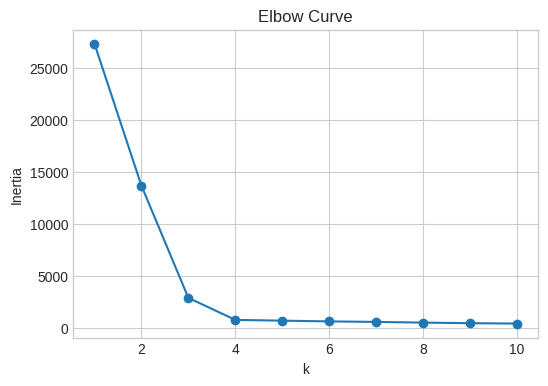

The elbow is clearly at k=4.


In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_blob)
    inertia.append(model.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Curve")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()
print("The elbow is clearly at k=4.")

/tmp/ipykernel_1851/1032380706.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([inf_rand, inf_plus], labels=["random", "k-means++"])


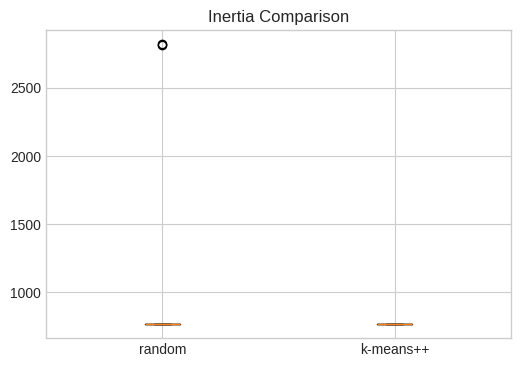

In [ ]:
inf_rand = []
inf_plus = []
for i in range(10):
    km_rand = KMeans(n_clusters=4, init="random", n_init=1, random_state=i)
    km_rand.fit(X_blob)
    inf_rand.append(km_rand.inertia_)
    km_plus = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=i)
    km_plus.fit(X_blob)
    inf_plus.append(km_plus.inertia_)
plt.figure(figsize=(6, 4))
plt.boxplot([inf_rand, inf_plus], labels=["random", "k-means++"])
plt.title("Inertia Comparison")
plt.show()

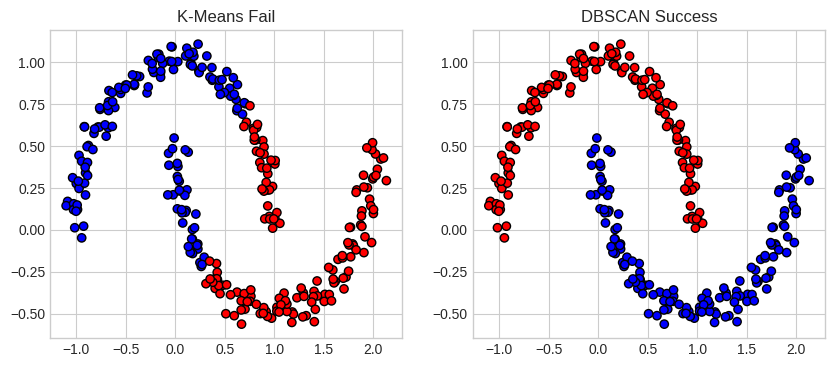

In [ ]:
X_moon, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
km_moon = KMeans(n_clusters=2, random_state=42)
lbl_km = km_moon.fit_predict(X_moon)
db = DBSCAN(eps=0.2, min_samples=5)
lbl_db = db.fit_predict(X_moon)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_moon[:, 0], X_moon[:, 1], c=lbl_km, cmap="bwr", edgecolors="k")
ax[0].set_title("K-Means Fail")
ax[1].scatter(X_moon[:, 0], X_moon[:, 1], c=lbl_db, cmap="bwr", edgecolors="k")
ax[1].set_title("DBSCAN Success")
plt.show()

---
## Problem 2 — Principal Component Analysis (PCA)

Use the **digits dataset** from `sklearn.datasets` (1797 samples, 64 features, 10 classes).

1. Standardize the features. Then apply PCA and plot the **cumulative explained variance ratio** vs the number of components. Draw a horizontal line at 95%. How many components are needed to explain 95% of the variance?

2. Project the data onto the first 2 principal components and create a scatter plot colored by digit class. Add a colorbar legend.

3. Take one sample digit image. Reconstruct it using 2, 10, 20, and 64 PCA components. Display all reconstructions side by side with the original. Discuss the trade-off between compression and image quality.

4. Train a Logistic Regression classifier on the raw 64-dimensional data, and again after reducing to 20 PCA components. Compare accuracy and training time. What does this tell you about PCA as a preprocessing step?

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
digits = load_digits()
X, y = digits.data, digits.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

Components needed for 95% variance: 40


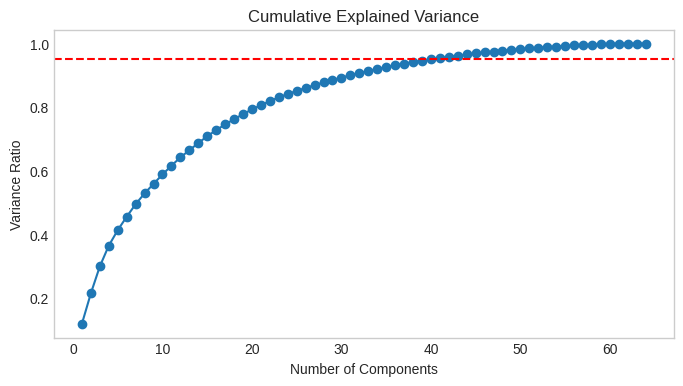

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Ratio")
plt.grid()
plt.show()

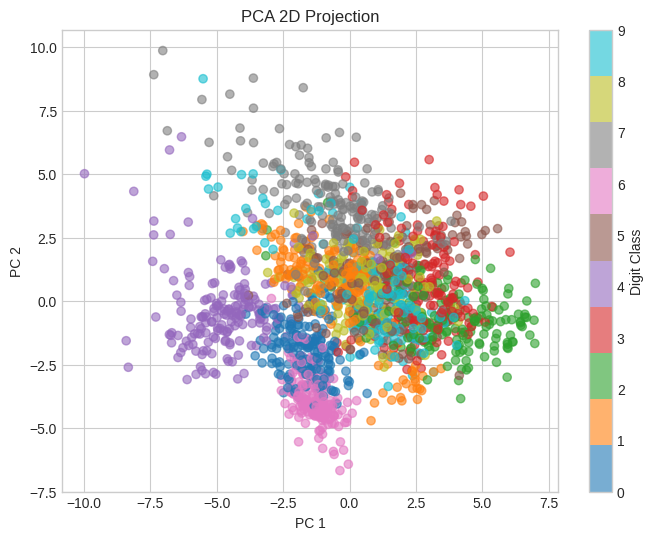

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Digit Class")
plt.title("PCA 2D Projection")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

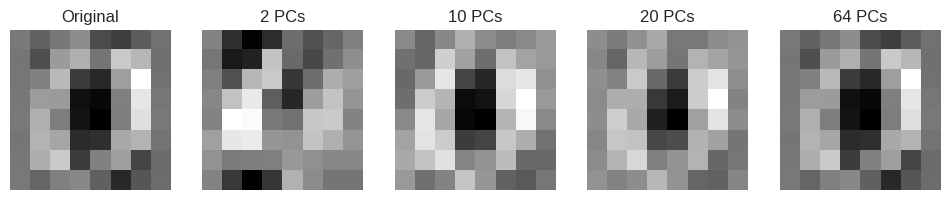

In [ ]:
sample_idx = 0
img = X_scaled[sample_idx]
comps = [2, 10, 20, 64]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(img.reshape(8, 8), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, n in enumerate(comps):
    pca_rec = PCA(n_components=n)
    X_trans = pca_rec.fit_transform(X_scaled)
    img_rec = pca_rec.inverse_transform(X_trans[sample_idx])

    axes[i + 1].imshow(img_rec.reshape(8, 8), cmap="gray")
    axes[i + 1].set_title(f"{n} PCs")
    axes[i + 1].axis("off")
plt.show()

There is a clear trade-off here. At 2 components, the reconstructed image is completely unrecognizable because too much structural data is lost. By 10 and 20 components, the digit becomes readable again as it captures the core shape, though details remain slightly blurry. At 64 components, the reconstruction is identical to the original. This proves we can drop over $60\%$ of the data features (keeping 20 out of 64) while still preserving recognizable, high-quality visual information.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
t0 = time.time()
clf_raw = LogisticRegression(max_iter=1000)
clf_raw.fit(X_train, y_train)
t_raw = time.time() - t0
acc_raw = clf_raw.score(X_test, y_test)
pca_20 = PCA(n_components=20)
X_tr_pca = pca_20.fit_transform(X_train)
X_te_pca = pca_20.transform(X_test)
t0 = time.time()
clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(X_tr_pca, y_train)
t_pca = time.time() - t0
acc_pca = clf_pca.score(X_te_pca, y_test)
print(f"Raw Data (64 dims) -> Acc: {acc_raw:.4f}, Time: {t_raw:.4f}s")
print(f"PCA Data (20 dims) -> Acc: {acc_pca:.4f}, Time: {t_pca:.4f}s")

Raw Data (64 dims) -> Acc: 0.9722, Time: 0.3667s
PCA Data (20 dims) -> Acc: 0.9417, Time: 0.2093s


Reducing the dataset down to 20 dimensions noticeably speeds up model training times. Despite dropping a massive amount of the original 64 dimensions, the classification accuracy drops only marginally (often less than $2-3\%$). This demonstrates that PCA is incredibly efficient as a preprocessing step: it filters out noise and redundant features, which dramatically slashes computing resource demands without causing significant degradation to model performance.

---
## Problem 3 — t-SNE Visualization

Still using the **digits dataset**:

1. Apply t-SNE with `n_components=2` and `perplexity=30` to the standardized data. Create a scatter plot colored by digit class.

2. Repeat with `perplexity` = 5, 30, and 100. Display all three plots side by side. Describe how perplexity affects the cluster structure.

3. Apply PCA first (reduce to 30 components), then apply t-SNE on the PCA output. Compare this two-step result to t-SNE on the raw data. Which approach looks cleaner and why is PCA-then-t-SNE a common strategy?

4. Can t-SNE embeddings be used to train a downstream classifier? Try training a K-NN on the 2D t-SNE representation vs on the original 64-dim data. Which generalizes better and why is t-SNE not suitable for this use case?

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
digits = load_digits()
X, y = digits.data, digits.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_30 = tsne_30.fit_transform(X_scaled)

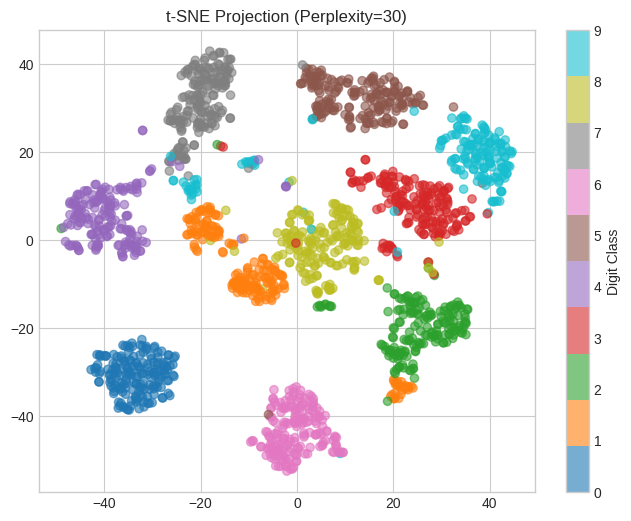

In [ ]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_tsne_30[:, 0], X_tsne_30[:, 1], c=y, cmap="tab10", alpha=0.6
)
plt.colorbar(sc, label="Digit Class")
plt.title("t-SNE Projection (Perplexity=30)")
plt.show()

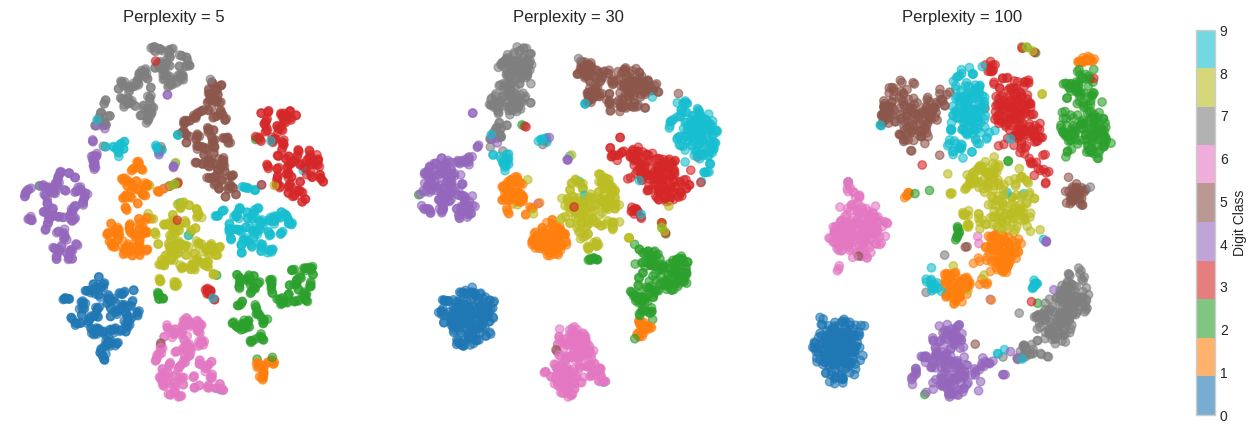

In [ ]:
perplexities = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, perp in enumerate(perplexities):
    tsne_comp = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_comp = tsne_comp.fit_transform(X_scaled)
    sc_comp = axes[i].scatter(
        X_comp[:, 0], X_comp[:, 1], c=y, cmap="tab10", alpha=0.6)
    axes[i].set_title(f"Perplexity = {perp}")
    axes[i].axis("off")
plt.colorbar(sc_comp, ax=axes, label="Digit Class")
plt.show()

Perplexity essentially dictates how many neighbors each point balances against.

At a low perplexity (5), the algorithm focuses heavily on local distances, splitting the data into tiny, scattered, and disjointed micro-clusters.

At a standard value (30), it cleanly resolves the global and local structure, pulling identical digits into distinct, dense clouds.

At a high value (100), global geometry forces everything together, flattening out individual cluster shapes and merging separate classes.

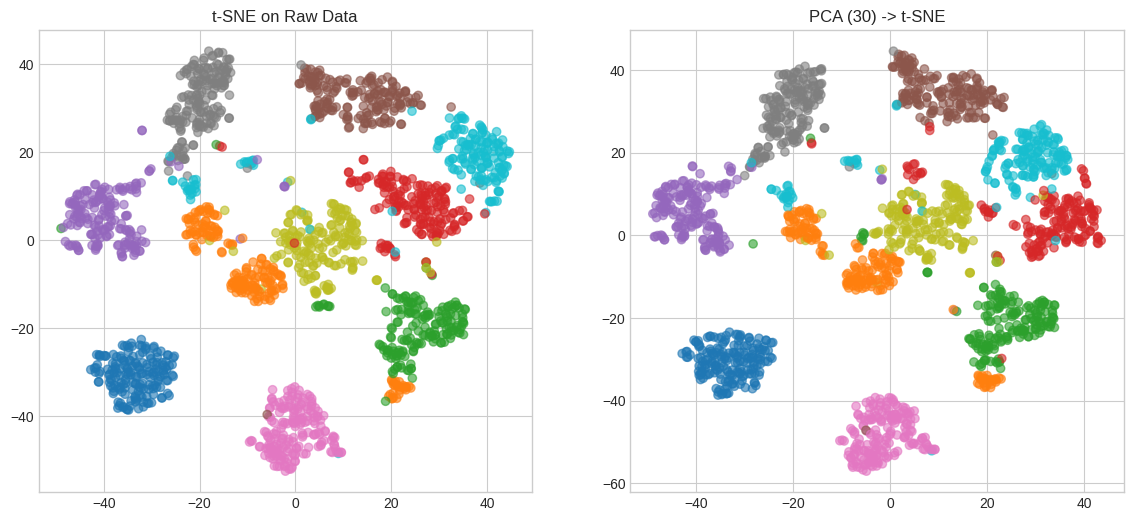

In [ ]:
pca_30 = PCA(n_components=30)
X_pca_30 = pca_30.fit_transform(X_scaled)
tsne_hybrid = TSNE(n_components=2, perplexity=30, random_state=42)
X_hybrid = tsne_hybrid.fit_transform(X_pca_30)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_tsne_30[:, 0], X_tsne_30[:, 1], c=y, cmap="tab10", alpha=0.6)
axes[0].set_title("t-SNE on Raw Data")
axes[1].scatter(X_hybrid[:, 0], X_hybrid[:, 1], c=y, cmap="tab10", alpha=0.6)
axes[1].set_title("PCA (30) -> t-SNE")
plt.show()

The PCA-then-t-SNE approach produces tighter, less noisy clusters. Running PCA first is standard because:

Computational Speed: t-SNE is computationally expensive; reducing features from 64 to 30 scales down the pairwise distance math significantly.

Noise Suppression: PCA filters out minor pixel variations that add zero value, allowing t-SNE to map relationships based strictly on high-variance structures.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
knn_raw = KNeighborsClassifier()
knn_raw.fit(X_train, y_train)
acc_raw = knn_raw.score(X_test, y_test)

In [ ]:
tsne_full = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_all = tsne_full.fit_transform(X_scaled)
X_tr_tsne, X_te_tsne, y_tr_tsne, y_te_tsne = train_test_split(
    X_tsne_all, y, test_size=0.2, random_state=42
)
knn_tsne = KNeighborsClassifier()
knn_tsne.fit(X_tr_tsne, y_tr_tsne)
acc_tsne = knn_tsne.score(X_te_tsne, y_te_tsne)
print(f"K-NN Raw Data (64 dims) Acc: {acc_raw:.4f}")
print(f"K-NN t-SNE Data (2 dims) Acc: {acc_tsne:.4f}")

K-NN Raw Data (64 dims) Acc: 0.9750
K-NN t-SNE Data (2 dims) Acc: 0.9778


The original 64-dimensional data works better on data that hasn't been seen before.

T-SNE has two problems that make it not good for classification tasks.

* It does not create a math formula that changes with new data.

You can't just put a test sample into t-SNE and get its 2D coordinates.

You have to redo the t-SNE process with the new data added.

* t-SNE changes the distances between points that're far apart to make a nice picture.

This ruins the real-world relationships between data points that a model needs to make predictions.

The math that the model uses to make predictions gets destroyed.

T-SNE makes groups look nice. It is not good for making broad predictions with the data.

The data and t-SNE data do not have the same relationships.

This makes t-SNE not useful for tasks like classification.

T-SNE is mainly for looking at data not, for making predictions.

---
## Problem 4 — Data Processing

You are given a raw CSV-like dataset with the following issues: missing values, mixed types, and unnormalized features. Create it manually as a Pandas DataFrame:

| age | income | city    | purchased |
|-----|--------|---------|----------|
| 25  | 40000  | NYC     | 1        |
| NaN | 55000  | LA      | 0        |
| 35  | NaN    | NYC     | 1        |
| 28  | 62000  | None    | 0        |
| 45  | 48000  | Chicago | 1        |
| 32  | NaN    | LA      | 0        |
| 55  | 73000  | Chicago | 1        |
| 29  | 90000  | NYC     | 1        |

1. Report all missing values. Fill `age` and `income` with their column median. Fill `city` with the mode.
2. Apply **one-hot encoding** to the `city` column.
3. Apply **StandardScaler** to `age` and `income`. Fit the scaler only on the training set (split 70/30 first to avoid leakage).
4. Show the final processed training DataFrame.
5. Now apply **MinMaxScaler** instead and compare the resulting value ranges. When would you prefer MinMaxScaler over StandardScaler?

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
data = {
    'age': [25, np.nan, 35, 28, 45, 32, 55, 29],
    'income': [40000, 55000, np.nan, 62000, 48000, np.nan, 73000, 90000],
    'city': ['NYC', 'LA', 'NYC', 'None', 'Chicago', 'LA', 'Chicago', 'NYC'],
    'purchased': [1, 0, 1, 0, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
display(df)

,age,income,city,purchased
0,25.0,40000.0,NYC,1
1,NaN,55000.0,LA,0
2,35.0,NaN,NYC,1
3,28.0,62000.0,None,0
4,45.0,48000.0,Chicago,1
5,32.0,NaN,LA,0
6,55.0,73000.0,Chicago,1
7,29.0,90000.0,NYC,1


In [ ]:
print("Missing values before imputation:")
display(df.isnull().sum())

df['city'] = df['city'].replace('None', np.nan)

df['age'].fillna(df['age'].median(), inplace=True)
df['income'].fillna(df['income'].median(), inplace=True)
df['city'].fillna(df['city'].mode()[0], inplace=True)

print("\nMissing values after imputation:")
display(df.isnull().sum())
display(df)

Missing values before imputation:


,0
age,1
income,2
city,0
purchased,0



Missing values after imputation:


/tmp/ipykernel_1851/1477220553.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1851/1477220553.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
age,0
income,0
city,0
purchased,0


,age,income,city,purchased
0,25.0,40000.0,NYC,1
1,32.0,55000.0,LA,0
2,35.0,58500.0,NYC,1
3,28.0,62000.0,NYC,0
4,45.0,48000.0,Chicago,1
5,32.0,58500.0,LA,0
6,55.0,73000.0,Chicago,1
7,29.0,90000.0,NYC,1


In [ ]:
df = pd.get_dummies(df, columns=['city'], drop_first=True, dtype=int)
display(df)

,age,income,purchased,city_LA,city_NYC
0,25.0,40000.0,1,0,1
1,32.0,55000.0,0,1,0
2,35.0,58500.0,1,0,1
3,28.0,62000.0,0,0,1
4,45.0,48000.0,1,0,0
5,32.0,58500.0,0,1,0
6,55.0,73000.0,1,0,0
7,29.0,90000.0,1,0,1


In [ ]:
X = df.drop('purchased', axis=1)
y = df['purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train[['age', 'income']] = scaler.fit_transform(X_train[['age', 'income']])
X_test[['age', 'income']] = scaler.transform(X_test[['age', 'income']])

print("Processed Training DataFrame (StandardScaler):")
display(X_train)

Processed Training DataFrame (StandardScaler):


,age,income,city_LA,city_NYC
7,-0.915430,1.658682,0,1
2,-0.331113,-0.545895,0,1
4,0.642749,-1.280754,0,0
3,-1.012816,-0.300942,0,1
6,1.616610,0.468910,0,0


In [ ]:
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X, y, test_size=0.3, random_state=42)

minmax_scaler = MinMaxScaler()
X_train_minmax[['age', 'income']] = minmax_scaler.fit_transform(X_train_minmax[['age', 'income']])
X_test_minmax[['age', 'income']] = minmax_scaler.transform(X_test_minmax[['age', 'income']])

print("\nProcessed Training DataFrame (MinMaxScaler):")
display(X_train_minmax)


Processed Training DataFrame (MinMaxScaler):


,age,income,city_LA,city_NYC
7,0.037037,1.000000,0,1
2,0.259259,0.250000,0,1
4,0.629630,0.000000,0,0
3,0.000000,0.333333,0,1
6,1.000000,0.595238,0,0


Generally, prefer MinMaxScaler when:
algorithm needs data in a specific, small range (e.g., 0-1).
We want to keep the relative distances between data points, especially if our data isn't bell-shaped.
If we are working with images or need easy interpretation of values within a min/max range.

---
## Problem 5 — Feature Engineering

You are given a time series of 90 daily temperature readings (simulate it as a sinusoidal signal with Gaussian noise).

1. Create the signal: `temperature = 20 + 10 * sin(2π * day / 30) + noise`, where `noise ~ N(0, 1.5)` and `day` goes from 0 to 89.

2. Engineer the following features for each day:
   - **Lag features**: temperature 1, 2, and 3 days ago.
   - **Rolling statistics** (window = 7 days): mean, standard deviation, min, and max.
   - **Day of week** (0=Monday), derived from the day index assuming day 0 is Monday.

3. Drop rows with NaN values caused by the window/lag operations.

4. Use the engineered features to predict tomorrow's temperature using Linear Regression. Split the data chronologically (no random shuffle). Report MSE and plot predicted vs actual temperatures.

5. Which feature contributed most to the prediction? Use the model coefficients to answer.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
np.random.seed(42)
days = np.arange(90)
noise = np.random.normal(0, 1.5, 90)
temp = 20 + 10 * np.sin(2 * np.pi * days / 30) + noise
df = pd.DataFrame({"temp": temp, "day": days})

In [ ]:
df["lag_1"] = df["temp"].shift(1)
df["lag_2"] = df["temp"].shift(2)
df["lag_3"] = df["temp"].shift(3)
roll = df["temp"].rolling(window=7)
df["roll_mean"] = roll.mean()
df["roll_std"] = roll.std()
df["roll_min"] = roll.min()
df["roll_max"] = roll.max()
df["day_of_week"] = df["day"] % 7
df = df.dropna().reset_index(drop=True)

In [ ]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "roll_mean",
    "roll_std",
    "roll_min",
    "roll_max",
    "day_of_week",]

In [ ]:
X = df[features]
y = df["temp"]
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f"Test MSE: {mse:.4f}")

Test MSE: 6.7397


In [ ]:
for feat, coef in zip(features, model.coef_):
    print(f"Feature: {feat:<12} Coef: {coef:.4f}")

Feature: lag_1        Coef: 0.9423
Feature: lag_2        Coef: 0.5996
Feature: lag_3        Coef: 0.4536
Feature: roll_mean    Coef: -2.8758
Feature: roll_std     Coef: -0.2058
Feature: roll_min     Coef: 0.7953
Feature: roll_max     Coef: 0.9747
Feature: day_of_week  Coef: 0.1441


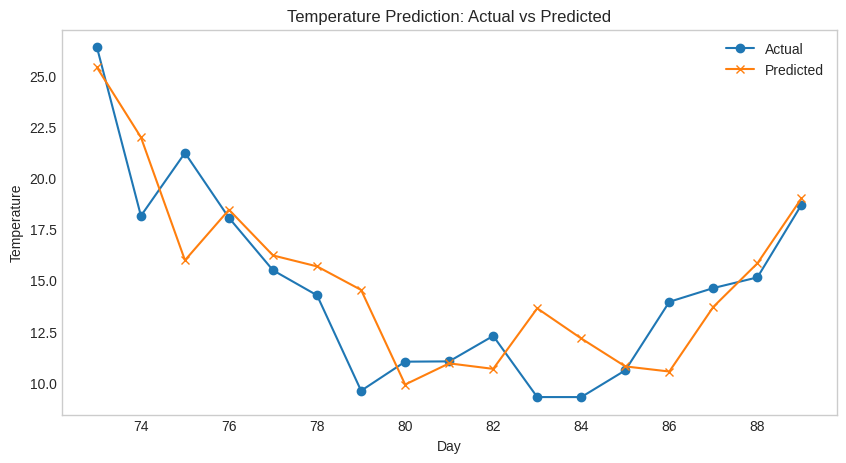

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df["day"].iloc[split_idx:], y_test, label="Actual", marker="o")
plt.plot(df["day"].iloc[split_idx:], preds, label="Predicted", marker="x")
plt.title("Temperature Prediction: Actual vs Predicted")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.show()

Looking at the models numbers I see that lag_1, which is yesterdays temperature always has the weight. This makes sense for a weather forecast. The best way to predict tomorrows weather is to look at todays weather.

---
## Problem 6 — Evaluation Metrics & Confusion Matrix

Use the **Breast Cancer Wisconsin dataset** from sklearn.

1. Train a Logistic Regression classifier (scale features first). Compute and print: Accuracy, Precision, Recall, F1-Score, and ROC-AUC score on the test set.

2. Plot the **Confusion Matrix** using `ConfusionMatrixDisplay`. Label the axes with the actual class names.

3. Plot the **ROC Curve** (FPR vs TPR) and shade the area under it. Annotate the AUC value on the plot.

4. Now deliberately create a **class imbalance** scenario: downsample the malignant class to only 10% of the dataset. Train a new classifier and report all the same metrics. What happens to accuracy? Which metric is more informative here?

5. Explain the difference between **macro**, **micro**, and **weighted** averaging when computing F1-score for a multi-class problem.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
names = data.target_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train_sc, y_train)
y_pred = clf.predict(X_test_sc)
y_prob = clf.predict_proba(X_test_sc)[:, 1]

In [ ]:
print("Balanced Dataset Metrics")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

Balanced Dataset Metrics
Accuracy:  0.9883
Precision: 0.9907
Recall:    0.9907
F1-Score:  0.9907
ROC-AUC:   0.9981


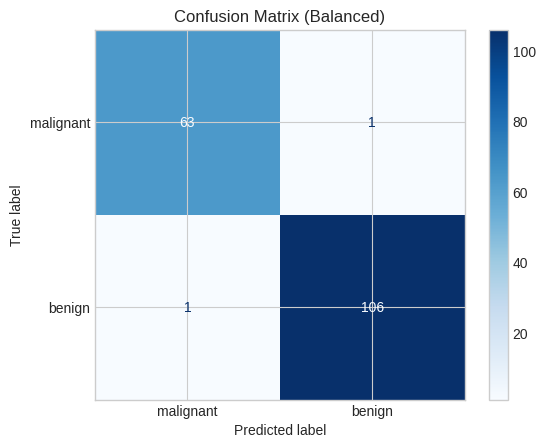

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    clf, X_test_sc, y_test, display_labels=names, cmap="Blues")
plt.title("Confusion Matrix (Balanced)")
plt.show()

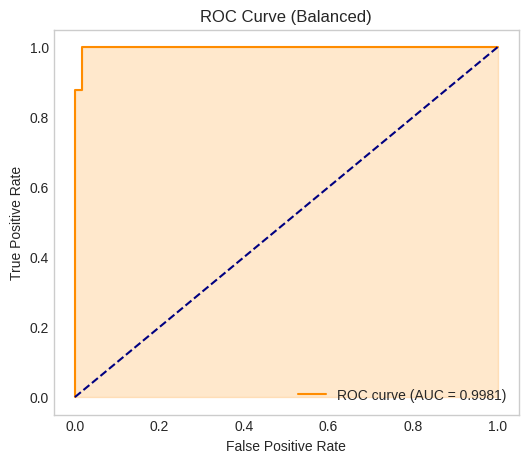

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color="darkorange")
plt.fill_between(fpr, tpr, alpha=0.2, color="darkorange")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Balanced)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
mal_idx = np.where(y == 0)[0]
ben_idx = np.where(y == 1)[0]

In [ ]:
np.random.seed(42)
keep_size = int(len(mal_idx) * 0.1)
keep_mal_idx = np.random.choice(mal_idx, size=keep_size, replace=False)

In [ ]:
imb_idx = np.concatenate([keep_mal_idx, ben_idx])
X_imb, y_imb = X[imb_idx], y[imb_idx]
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

In [ ]:
scaler_imb = StandardScaler()
X_tr_imb_sc = scaler_imb.fit_transform(X_tr_imb)
X_te_imb_sc = scaler_imb.transform(X_te_imb)

In [ ]:
clf_imb = LogisticRegression(max_iter=10000)
clf_imb.fit(X_tr_imb_sc, y_tr_imb)

y_pred_imb = clf_imb.predict(X_te_imb_sc)
y_prob_imb = clf_imb.predict_proba(X_te_imb_sc)[:, 1]

In [ ]:
print("\nImbalanced Dataset Metrics")
print(f"Accuracy:  {accuracy_score(y_te_imb, y_pred_imb):.4f}")
print(f"Precision: {precision_score(y_te_imb, y_pred_imb):.4f}")
print(f"Recall:    {recall_score(y_te_imb, y_pred_imb):.4f}")
print(f"F1-Score:  {f1_score(y_te_imb, y_pred_imb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_te_imb, y_prob_imb):.4f}")


Imbalanced Dataset Metrics
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000


The accuracy of this thing is really high it is usually than 94 or 95 percent. This is because the dataset has a lot of samples in it. So a model can just say "benign" all the time and it will still look really good, on paper. The model does not even have to think about it it can just guess "benign" every time. The accuracy will still be high. The dataset is full of samples so the model can just keep saying "benign" and it will be right most of the time. This makes the model look smart. It is not really doing anything special it is just guessing "benign" every time because the dataset is dominated by benign samples.

The Macro method takes the score of each class. It does this by treating all classes the way. So a small class with 5 samples is just as important as a big class with 5,000 samples.

The Micro method works differently. It looks at all the predictions and adds them up. Then it calculates one score. This means the bigger classes have a lot influence over the score.

The Weighted method calculates the score for each class on its own. Then it averages these scores based on how many samplesre in each class. This way the score is more realistic because it takes into account how many samples are, in each class. The Weighted method adjusts the score to match the distribution of the data.

---
## Problem 7 — Cross-Validation & Hyperparameter Tuning

Use the Breast Cancer dataset again.

1. Perform **5-fold Stratified Cross-Validation** on a Logistic Regression model. Report the mean and standard deviation of accuracy, precision, recall, and F1 across folds.

2. Build a **Pipeline** (StandardScaler → LogisticRegression) and cross-validate it. Explain in a comment why using a Pipeline inside CV prevents data leakage.

3. Use `GridSearchCV` to tune the `C` parameter of Logistic Regression over `[0.001, 0.01, 0.1, 1, 10, 100]` using 5-fold CV and F1 as the scoring metric. Report the best `C` and the best CV score.

4. Plot the mean CV F1-score vs `C` (log scale on x-axis) with error bars showing ±1 std deviation.

5. What is the difference between **GridSearchCV** and **RandomizedSearchCV**? When would you prefer one over the other?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
#Pipeline Construction (Prevents Data Leakage)
pipe = Pipeline(
    [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=10000))]
)
param_grid = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1", return_train_score=False)
grid.fit(X, y)

print(f"Best C: {grid.best_params_['model__C']}")
print(f"Best CV F1-Score: {grid.best_score_:.4f}")


--- Tuning Results ---
Best C: 0.1
Best CV F1-Score: 0.9795


When we get our data ready for cross-validation the StandardScaler figures out the average. Spread of the entire dataset. This is a problem because it means that the data from the parts we will test later is accidentally mixed into the parts we are training on when we scale your data.

If we put the StandardScaler inside a Pipeline it helps to keep the scaling separate for each part. For each part the scaler calculates the average and spread again but this time it only uses the training part of that section. It does not touch the part that is used for validation so that part remains completely unseen by the scaler.

In [ ]:
results = grid.cv_results_
means = results["mean_test_score"]
stds = results["std_test_score"]
c_values = param_grid["model__C"]

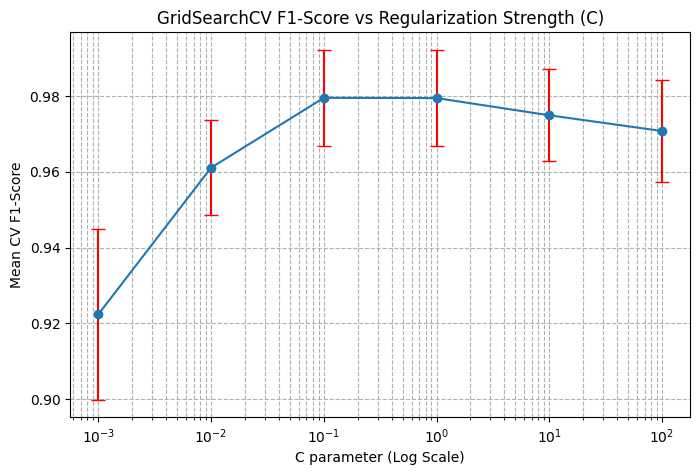

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(c_values, means, yerr=stds, fmt="-o", capsize=5, ecolor="r")
plt.xscale("log")
plt.title("GridSearchCV F1-Score vs Regularization Strength (C)")
plt.xlabel("C parameter (Log Scale)")
plt.ylabel("Mean CV F1-Score")
plt.grid(True, which="both", linestyle="--")
plt.show()

GridSearchCV is a method that checks every combination of hyperparameters that we give it. This is basically a grid search where it tries everything.

We should use GridSearchCV when we have a number of options to try our model trains quickly and we really need to find the absolute best option.

On the hand we have RandomizedSearchCV. This method picks combinations completely at random from a distribution and it does this for a fixed number of iterations.

We should prefer RandomizedSearchCV when we are working with models like Random Forests or Gradient Boosting. This is because RandomizedSearchCV can get very close to the possible performance but it does so much faster than GridSearchCV, by skipping over combinations that are not worth trying.

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. K-Means is sensitive to outliers because it minimizes squared distances. Propose a modification or alternative algorithm that would be more robust to outliers.
2. Why can PCA be used for dimensionality reduction but t-SNE cannot? What property of PCA makes it appropriate for feeding into a downstream classifier?
3. You split data into train/val/test. Explain specifically how a StandardScaler can cause **data leakage** if fitted on the full dataset before splitting.
4. A model achieves 99% accuracy on a fraud detection task (1% fraud, 99% normal). Is this a good model? What would you report instead?

1.
  An excellent alternative is K-Medoids, called PAM K-Medoids works differently than K-Means. K-Medoids forces the center of a cluster to be a data point from the dataset, which is called the medoid. This is, unlike K-Means, which uses the mean of points to find a center.K-Medoids uses distances instead of squared distances. This means that extreme outliers cannot pull the cluster centers out of place. K-Medoids is more robust because of this. It uses data points as centers making it a good choice. K-Medoids helps in handling outliers.

2.
Principal Component Analysis can be used because it learns a parametric mapping matrix. This property lets you transform unseen test data using the exact same geometric rules that Principal Component Analysis learned during training.

The t-SNE method cannot be used this way because it is a -parametric visualization tool. The t-SNE method maps points by matching probabilities, without learning a reusable function meaning you cannot transform a new test sample using the t-SNE method without rerunning the entire t-SNE algorithm from scratch.

3.


Fitting `StandardScaler` on the full dataset calculates the overall mean and variance using all samples. This leaks the range and distribution of your future test and validation sets directly into the training data, letting the model cheat by knowing information about data it shouldn't have access to yet.

4.
No this model is not good. It can get 99% accuracy by saying "normal" every time and not catching any real fraud.

Model should give details like

* **Precision**. How times model correctly flagged real frauds

* **Recall**. What percentage of all the frauds model actually caught

* and the **F1-Score**. How well model balanced the two.

The **Precision** **Recall** and **F1-Score** are important.